In [ ]:
# things to add
# 2️⃣ Energy optimality comparison (for 1 & 2)


In [9]:
# algorithm testing for
# Greedy_SOSP_Update and Robust_MOSP_Update

# importing stuffs
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from mpl_toolkits.mplot3d import Axes3D


In [10]:
# ablation study for Greedy_SOSP_Update consist of two parameters
# no of nodes (n) and edge probablity (e)

# n can be 2,4,6,.....1000 etc
# e can be 0.1,0.2,.....1 etc

# e = 1 means all the nodes of a graph are equally connected and
# drone (obj) can move easily from one node to another without hindrence
# e = 0/0.2 etc signifies some nodes are not well connected
# and drone (obj) can't move freely from one node to another in traversal

# this ablation study measure the performance of drone (obj) routing
# w.r.t. no of nodes (n) and edge probablity (e)
# how run time behaves w.r.t. n and e

# incrementing node sizes twice the previous
NODE_SIZES = [4, 8, 16, 32, 64, 128, 256, 512, 1024]
EDGE_PROBS = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]  # edge probablity for nodes

REPEAT = 10  # repetation of 10


In [12]:
# DON'T RUN THIS TWICE

# for Greedy_SOSP_Update
from greedy_sosp_update import Greedy_SOSP_Update
from utils.generate_graph import generate_graph

results=[] # for storing ablation results
total_runs = len(NODE_SIZES)*len(EDGE_PROBS) * REPEAT # total no of running exp. 

with tqdm(total=total_runs) as pbar:
    for n in NODE_SIZES:
        for prob in EDGE_PROBS:
            for r in range(REPEAT):
                G = generate_graph(n, prob) # for each node having all the prob generate graph

                # for each node and edge probablity, checking performance of greedy_sosp_update
                start = time.perf_counter() # starting runtime
                Greedy_SOSP_Update(G) # greedy sosp update algorithm running
                end = time.perf_counter() # ending runtime
                runtime = end - start # total runtime by algo

                # storing results
                results.append({
                    "nodes":n,
                    "edge_prob":prob,
                    "runtime":runtime
                })

                pbar.update(1) # for updating tqdm


100%|██████████| 540/540 [01:20<00:00,  6.73it/s]  


In [13]:
# total time taken 1.20.3
# DON'T RUN THIS AGAIN
df = pd.DataFrame(results)
df.to_csv("greedy_sosp_update_ablation_results.csv", index=False)


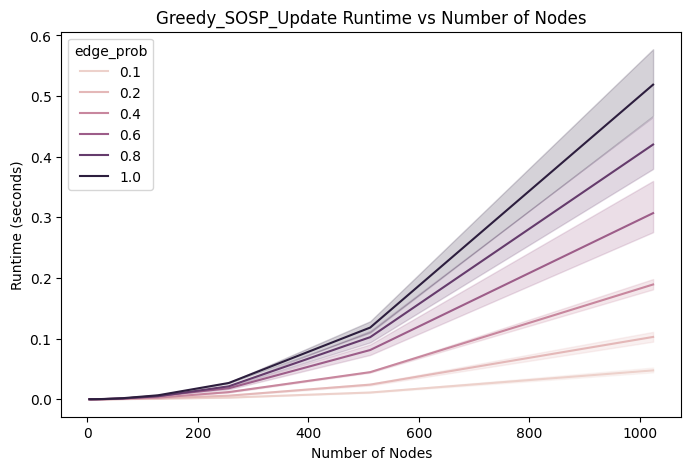

In [15]:

# run time vs nodes plot
plt.figure(figsize=(8, 5))

sns.lineplot(data=df,
             x="nodes",
             y="runtime",
             hue="edge_prob",
             estimator="mean")

plt.title("Greedy_SOSP_Update Runtime vs Number of Nodes")
plt.xlabel("Number of Nodes")
plt.ylabel("Runtime (seconds)")

plt.show()


# Greedy_SOSP_Update Runtime vs Number of Nodes explaination
# the plot shows how runtime changes with no of nodes and edge probablity changes

# for nodes: larger value means bigger graph
# for runtime: higher value means slower execution

# edge probablity
# 0.1 -> very sparse graph
# 0.2 -> sparse graph
# 1.0 -> fully connected

# all line goes upward means
# runtime increases as nodes increases
# the algorithm takes more time when graph size grows

# from the graph it also shows that
# high edge probablities (0.8, 1.0) have higher runtime

# from the datapoints
# n = 1024
# e = 0.1 -> runtime = 0.04
# e = 1.0 -> runtime = 0.44
# at higher edge probablity (dense graph), algorithm works 10 times slower

# the shaded region represents variance of the runtime by algorithm
# smaller shaded region = stable runtime
# larger shaded region = runtime fluctuates more


# from the plot
# for incremental graph having edge probablities
# let say number of ndoes = n
# number of edges = m
# and m depends on nodes (n) and edge probablity (p)
# as p increases, edges increase dramatically leads to runtime grows

# we can say that
# runtime proportionals number of nodes (n)
# runtime proportionals graph density (m) (graph density inc as edges inc)
# time complexity: O(m+n)


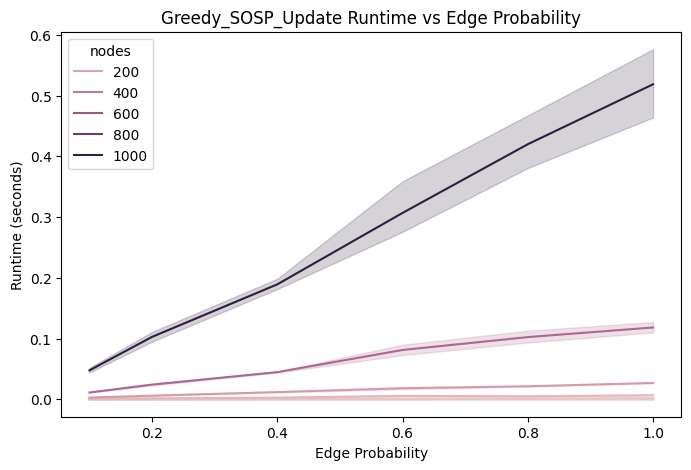

In [18]:
# runtime vs edge probablity
plt.figure(figsize=(8, 5))

sns.lineplot(data=df,
             x="edge_prob",
             y="runtime",
             hue="nodes",
             estimator="mean")

plt.title("Greedy_SOSP_Update Runtime vs Edge Probability")
plt.xlabel("Edge Probability")
plt.ylabel("Runtime (seconds)")

plt.show()


# Greedy_SOSP_Update Runtime vs Edge Probability Explaination
# this graph representing the relationship between edge probablity and runtime

# as the edge probablity increases, runtime increases
# the nodes are given in different shades of color

# from dataset
# for node 1024
# p = 0.1 -> runtime = 0.04
# p = 0.4 -> runtime = 0.20
# p = 1.0 -> runtime = 0.44

# at each edge probablity inc. number of edges increases dramatically
# edges increases quadratically
# more edges -> algorithm check more neighbors -> runtime increases

# shaded regions represents variation in the runtime
# using the previous logic we can say that
# time complexity: O(m+n)
# n = no of nodes
# m = no of edges

# we can conclude that algorithm becomes slower when graphs become larger and denser
# cause it must process more nodes and edges


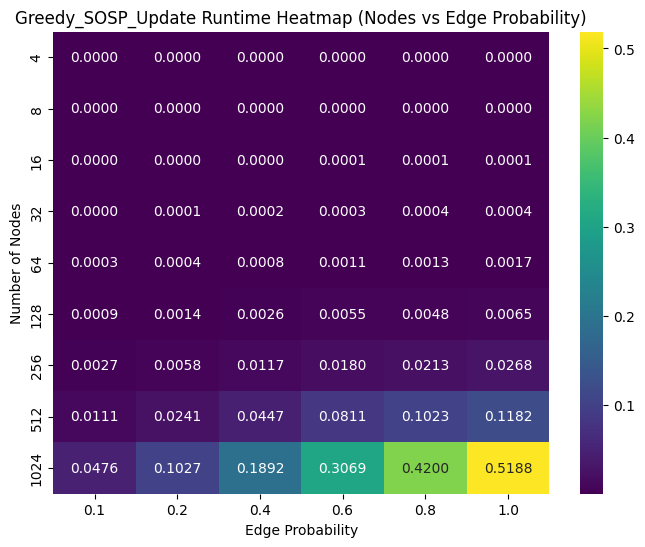

In [19]:
# heatmap n vs e
pivot = df.pivot_table(values="runtime",
                       index="nodes",
                       columns="edge_prob",
                       aggfunc=np.mean)

plt.figure(figsize=(8, 6))

sns.heatmap(pivot,
            annot=True,
            fmt=".4f",
            cmap="viridis")

plt.title("Greedy_SOSP_Update Runtime Heatmap (Nodes vs Edge Probability)")
plt.xlabel("Edge Probability")
plt.ylabel("Number of Nodes")

plt.show()


# Greedy_SOSP_Update Runtime Heatmap (Nodes vs Edge Probability) explaination

# x axis represents edge probablity. moving right graph becomes more connected
# y axis represents number of nodes. moving downwards, graph becomes larger
# colored boxes represents runtime for nodes along with edge probablity
# example
# nodes = 256
# p = 0.4
# runtime = 0.0114 s
# meaning: Greedy_SOSP_Update takes 0.0114 seconds to run on a graph with 256 nodes and edge probablity 0.4

# color codings:
# dark purple: very fast
# green : medium runtime
# yellow : slowest runtime

# time complexity: O(n+m)
# n = number of nodes
# m = number of edges


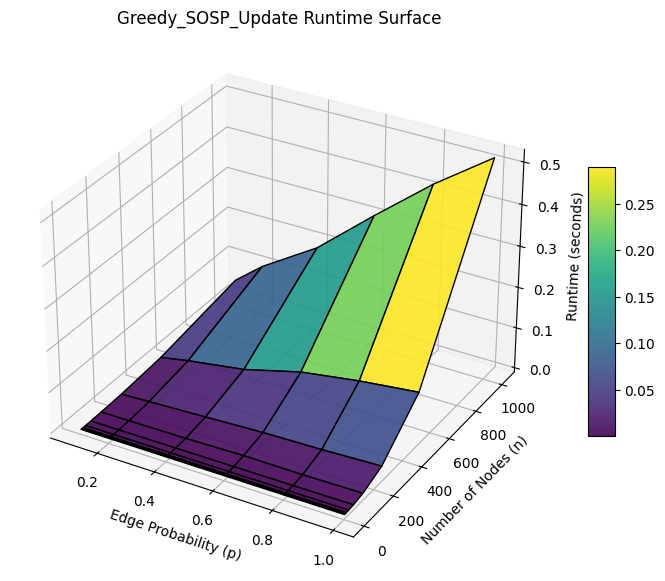

In [20]:

# a 3D representation of nodes, edge probablity and runtime

pivot = df.pivot_table(
    values="runtime",
    index="nodes",
    columns="edge_prob",
    aggfunc=np.mean
)

nodes = pivot.index.values
edge_probs = pivot.columns.values

X, Y = np.meshgrid(edge_probs, nodes)
Z = pivot.values

# X -> edge probablity
# Y -> node counts
# Z -> runtime


fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surface = ax.plot_surface(
    X, Y, Z,
    cmap='viridis',
    edgecolor='k',
    alpha=0.9
)

ax.set_xlabel("Edge Probability (p)")
ax.set_ylabel("Number of Nodes (n)")
ax.set_zlabel("Runtime (seconds)")
ax.set_title("Greedy_SOSP_Update Runtime Surface")
fig.colorbar(surface, shrink=0.5, aspect=10)
# plt.savefig("runtime_surface_plot.png", dpi=300, bbox_inches="tight")

plt.show()

# Greedy_SOSP_Update Runtime Surface interpretation
# surface rises as nodes increases
# surface rises as edge probablity increases
# highest peak occurs as p = 1.0 and n = 1024


In [22]:
# DON'T RUN THIS TWICE

# for Robust_MOSP_Update
from utils.generate_graph import generate_graph
from robust_mosp_update import Robust_MOSP_Update

results = []
total_runs = len(NODE_SIZES) * len(EDGE_PROBS) * \
    REPEAT  # total number of running time

with tqdm(total=total_runs) as pbar:
    for n in NODE_SIZES:
        for p in EDGE_PROBS:
            for r in range(REPEAT):
                G = generate_graph(n, p)
                start = time.perf_counter()
                Robust_MOSP_Update(G)  # running robust_mosp_update algo
                end = time.perf_counter()
                runtime = end - start  # runtime for running algo

                results.append({
                    "nodes": n,
                    "edge_prob": p,
                    "runtime": runtime
                })

                pbar.update(1)


  0%|          | 0/540 [00:00<?, ?it/s]c:\Users\USER\ES522AIProject\venv\Lib\site-packages\numpy\_core\_methods.py:188: RuntimeWarning: invalid value encountered in subtract
  x = um.subtract(arr, arrmean, out=...)
100%|██████████| 540/540 [25:13<00:00,  2.80s/it] 


In [ ]:
# took total time of 25.13.5

# DON'T RUN THIS AGAIN
df2 = pd.DataFrame(results)
df2.to_csv("robust_mosp_update_ablation_results.csv", index=False)


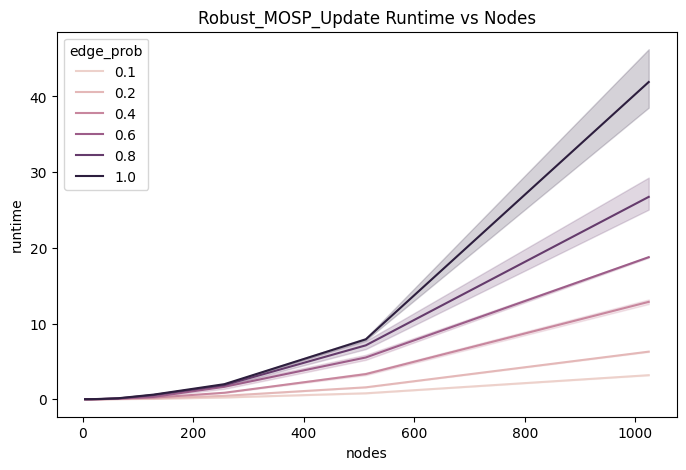

In [24]:
# plotting runtime vs nodes
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=df2,
    x="nodes",
    y="runtime",
    hue="edge_prob",
    estimator="mean"
)

plt.title("Robust_MOSP_Update Runtime vs Nodes")
plt.show()


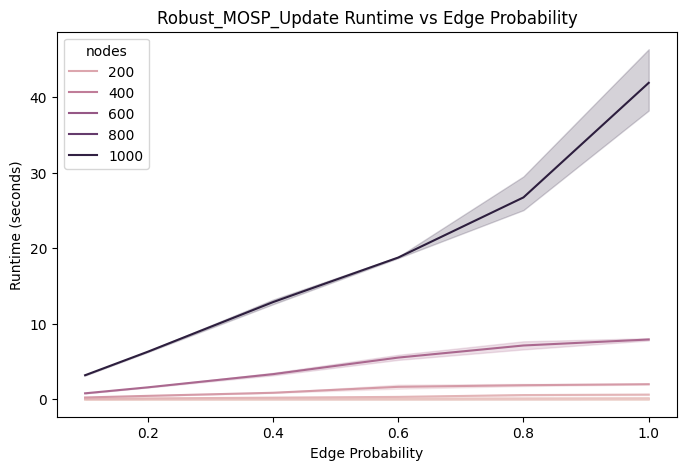

In [25]:
# Runtime vs Edge probablity
plt.figure(figsize=(8, 5))

sns.lineplot(data=df2,
             x="edge_prob",
             y="runtime",
             hue="nodes",
             estimator="mean")

plt.title("Robust_MOSP_Update Runtime vs Edge Probability")
plt.xlabel("Edge Probability")
plt.ylabel("Runtime (seconds)")

plt.show()


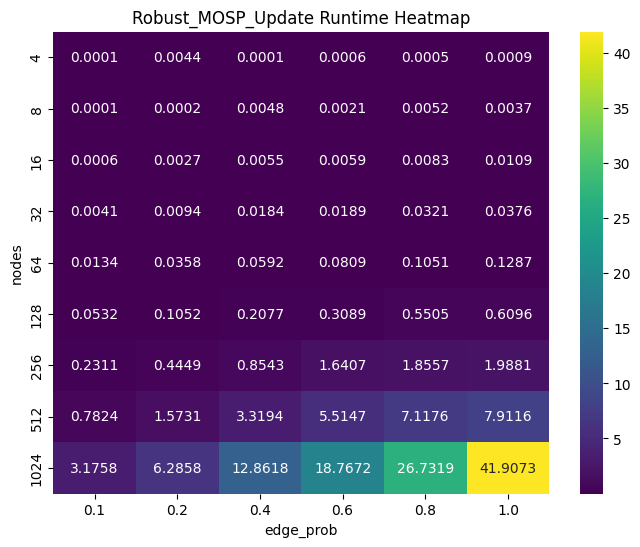

In [26]:
# nodes vs edge probablity
pivot = df2.pivot_table(
    values="runtime",
    index="nodes",
    columns="edge_prob",
    aggfunc=np.mean
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".4f",
    cmap="viridis"
)

plt.title("Robust_MOSP_Update Runtime Heatmap")
plt.show()


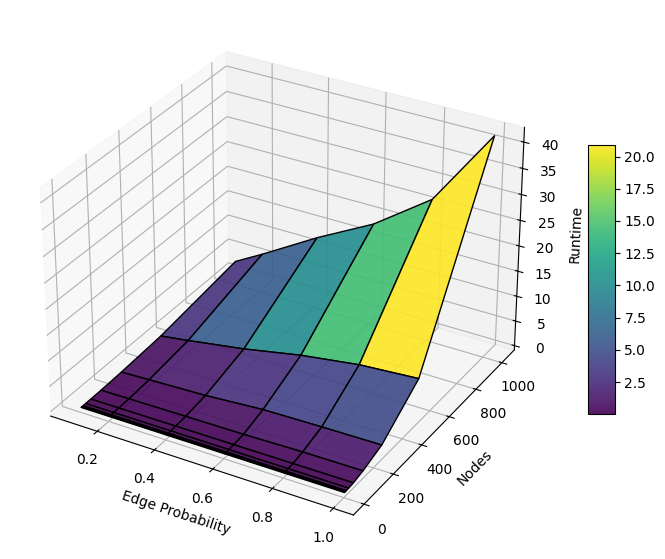

In [27]:
# 3D surface plot
from mpl_toolkits.mplot3d import Axes3D

nodes = pivot.index.values
edge_probs = pivot.columns.values

X, Y = np.meshgrid(edge_probs, nodes)
Z = pivot.values

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surface = ax.plot_surface(
    X, Y, Z,
    cmap='viridis',
    edgecolor='k',
    alpha=0.9
)


ax.set_xlabel("Edge Probability")
ax.set_ylabel("Nodes")
ax.set_zlabel("Runtime")
fig.colorbar(surface, shrink=0.5, aspect=10)

plt.show()


In [28]:
# time complexity
# O(k*(n+m)+m log n)

# possible upgradations
# for ablation studies of algorithm 2
# k = number of scenarios
# k should also vary like 2, 4, 6 etc
# and with each varying scenario show runtime vs scenarios
